In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from utils import *

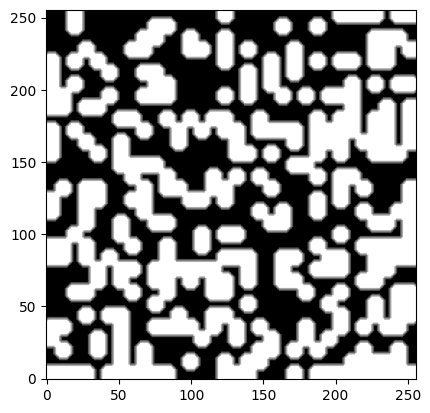

In [15]:
df = pd.read_csv('../working/mixer_256/topology_1.dat')
example = df['lambda'].to_numpy().reshape(256, 256)
plt.imshow(example, cmap='gray', origin='lower')

In [26]:
dataset_dir = '../working/mixer_256'
height = width = 256

files = os.listdir(dataset_dir)
files = [f for f in files if f.endswith('.dat')]
files.sort()

coords_file = pd.read_csv(f'{dataset_dir}/coordinates.csv')

inputs = []
outputs = []
for f in files:
    print(f)
    df = pd.read_csv(f'{dataset_dir}/{f}').drop(columns=['cellI'])
    df['x'] = coords_file['x']
    df['y'] = coords_file['y']
    df['z'] = coords_file['z']
    df = df.to_numpy().T.reshape(-1, height, width)
    inputs.append(df[4:])
    outputs.append(df[0:4])
    break

topology_0.dat


In [27]:
np.array(inputs).shape, np.array(outputs).shape

((1, 4, 256, 256), (1, 4, 256, 256))

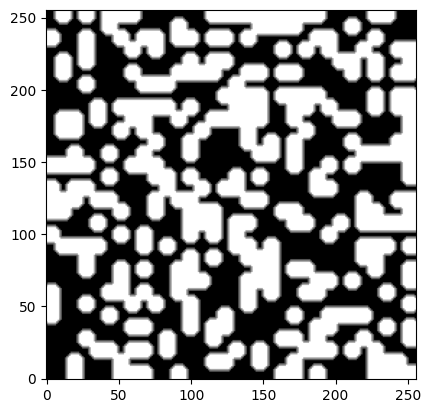

In [28]:
plt.imshow(inputs[0][0], cmap='gray', origin='lower')

In [29]:
coords_array = coords_file.drop(columns=['cellI']).to_numpy()

In [30]:
coords_array.shape

(65536, 4)

In [31]:
coords_array

array([[2.5000e-04, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       [7.5000e-04, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       [1.2500e-03, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       ...,
       [1.2675e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10],
       [1.2725e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10],
       [1.2775e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10]], shape=(65536, 4))

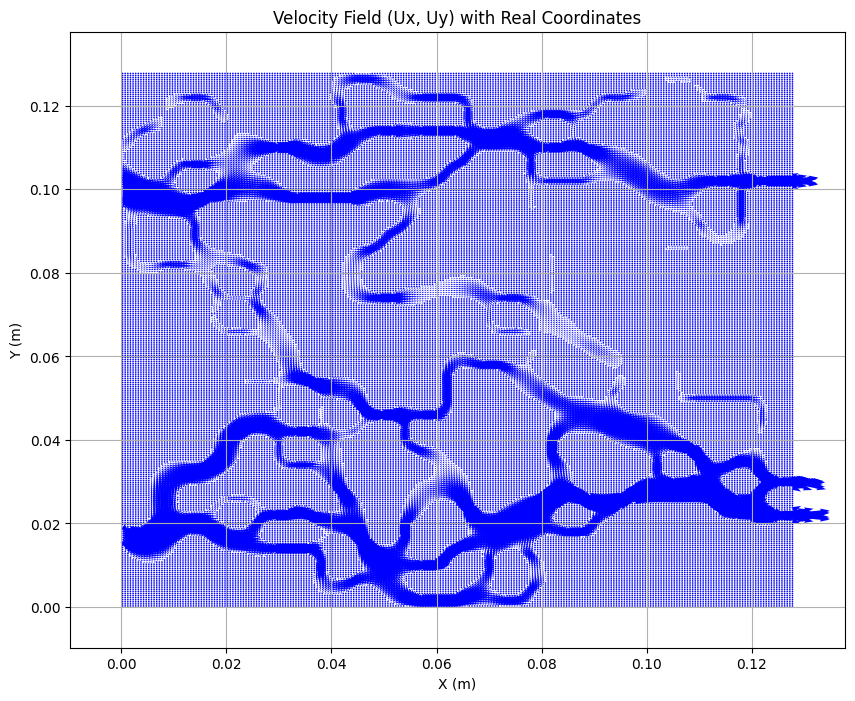

In [33]:
plot_quiver(outputs[0], coords_array, quiver_scale=1e2)

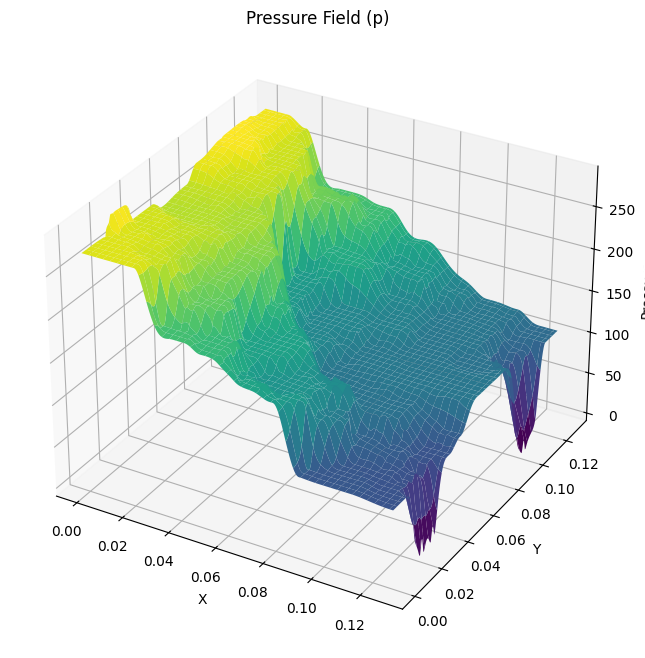

In [34]:
plot_pressure(outputs[0], coords_array)

In [8]:
# Save
inputs = np.array(inputs)
outputs = np.array(outputs)
np.savez('../data/mixer_128.npz', inputs=inputs, outputs=outputs)

In [2]:
data = np.load('../data/mixer_256.npz')
print(data['inputs'].shape, data['outputs'].shape)

(734, 4, 256, 256) (734, 4, 256, 256)


In [3]:
x, y = data['inputs'][:5], data['outputs'][:5]
print(x.shape, y.shape)

(5, 4, 256, 256) (5, 4, 256, 256)


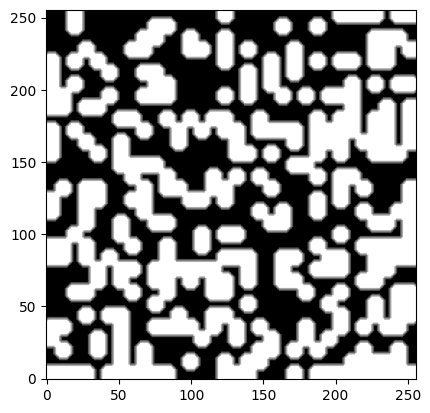

In [13]:
plt.imshow(x[1, 0], cmap='gray', origin='lower')

In [7]:
coords_array = pd.read_csv(f'../working/coordinates_256.csv').to_numpy()
coords_array

array([[0.0000e+00, 2.5000e-04, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       [1.0000e+00, 7.5000e-04, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       [2.0000e+00, 1.2500e-03, 2.5000e-04, 1.0000e-03, 5.0000e-10],
       ...,
       [6.5533e+04, 1.2675e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10],
       [6.5534e+04, 1.2725e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10],
       [6.5535e+04, 1.2775e-01, 1.2775e-01, 1.0000e-03, 5.0000e-10]],
      shape=(65536, 5))

In [8]:
coords = data['inputs'][0, -3:, :, :].reshape(3, -1).T
coords

array([[0.00025, 0.00025, 0.001  ],
       [0.00075, 0.00025, 0.001  ],
       [0.00125, 0.00025, 0.001  ],
       ...,
       [0.12675, 0.12775, 0.001  ],
       [0.12725, 0.12775, 0.001  ],
       [0.12775, 0.12775, 0.001  ]], shape=(65536, 3))

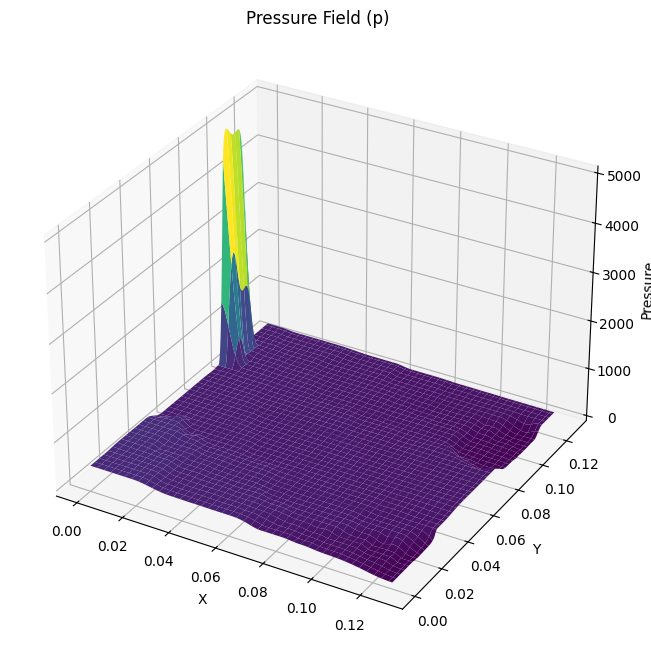

In [14]:
plot_pressure(data['outputs'][1], coords)

In [ ]:
# Prepare test data
dataset_dir = '../data/mixer_64_test'
height = width = 64

files = os.listdir(dataset_dir)
files = [f for f in files if f.endswith('.dat')]
files.sort()

coords_file = pd.read_csv(f'{dataset_dir}/coordinates.csv')

inputs = []
outputs = []
for f in files:
    print(f)
    df = pd.read_csv(f'{dataset_dir}/{f}').drop(columns=['cellI'])
    df['x'] = coords_file['x']
    df['y'] = coords_file['y']
    df['z'] = coords_file['z']
    df = df.to_numpy().T.reshape(-1, height, width)
    inputs.append(df[4:])
    outputs.append(df[0:4])
    
np.array(inputs).shape, np.array(outputs).shape

In [ ]:
# Save
inputs = np.array(inputs)
outputs = np.array(outputs)
np.savez('../data/mixer_64_test.npz', inputs=inputs, outputs=outputs)

In [ ]:
# Check for matches in inputs with training data
train_data = np.load('../data/mixer_64.npz')
test_data = np.load('../data/mixer_64_test.npz')
train_inputs = train_data['inputs']
test_inputs = test_data['inputs']

matches = []
for i, test_input in enumerate(test_inputs):
    for j, train_input in enumerate(train_inputs):
        if np.array_equal(test_input, train_input):
            matches.append((i, j))
            print(f'Test sample {i} matches Train sample {j}')